In [2]:
import torch
import torchvision
import torch.nn as nn
from torchvision import models
import torchvision.transforms.v2 as tv_tr
from torch import optim
import torch.utils.data as data
from torchvision import io
import os
import matplotlib.pyplot as plt
from pathlib import Path

import xml.etree.ElementTree as ET
import numpy as np
import cv2

Загрузим датасет с Kaggle для сегментации оружия

In [4]:
!pip install opendatasets

In [5]:
import opendatasets as od
# Maksik Yme, KGAT_da3d010cc57b0852104969455884bb0f
od.download("https://www.kaggle.com/datasets/trainingdatapro/people-with-guns-segmentation-and-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Maksik Yme
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/trainingdatapro/people-with-guns-segmentation-and-detection


100%|██████████| 66.4M/66.4M [00:00<00:00, 106MB/s]


Так как необходимые аннотации находятся в xml формате вместе  сне нужной информацией, необходима предобработка

In [6]:
def convert_cvat_to_masks(xml_path, output_dir, target_label="gun"):
    os.makedirs(output_dir, exist_ok=True)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    for image_tag in root.findall("image"):
        img_name = image_tag.get("name")           # "images/0.jpg"
        width = int(image_tag.get("width"))
        height = int(image_tag.get("height"))

        mask = np.zeros((height, width), dtype=np.uint8)

        for poly in image_tag.findall("polygon"):
            if poly.get("label") != target_label:
                continue
            points_str = poly.get("points")
            pts = []
            for pair in points_str.split(";"):
                x_str, y_str = pair.split(",")
                pts.append([float(x_str), float(y_str)])
            pts = np.array(pts, dtype=np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [pts], color=255)

        base_name = os.path.basename(img_name)               # "0.jpg"
        mask_name = os.path.splitext(base_name)[0] + ".png"    # "0.png"
        cv2.imwrite(os.path.join(output_dir, mask_name), mask)

In [7]:
convert_cvat_to_masks("people-with-guns-segmentation-and-detection/annotations.xml", "people-with-guns-segmentation-and-detection/masks")

In [8]:
class CegmentationDataset(data.Dataset):
    def __init__(self, paths, img_transform = None, mask_transform = None):
      self.paths = paths
      self.img_transform = img_transform
      self.mask_transform = mask_transform

      path = os.path.join(paths,'images')
      files_list = sorted(os.listdir(path), key = lambda x: int(Path(x).stem))
      self.length = len(files_list)
      self.images = list(map(lambda _x: os.path.join(path,_x), files_list))

      path = os.path.join(paths,'masks')
      masks_list = sorted(os.listdir(path), key = lambda x : int(Path(x).stem))
      self.masks = list(map(lambda _x: os.path.join(path, _x), masks_list))

    def __getitem__(self, idx):
        image_vector = io.read_image(self.images[idx])
        if self.img_transform is not None:
          image_vector = self.img_transform(image_vector)

        mask_vector = io.read_image(self.masks[idx])
        if self.mask_transform is not None:
          mask_vector = self.mask_transform(mask_vector)
        return image_vector, mask_vector

    def __len__(self):
        return self.length


In [9]:

class Cegment_UNet(nn.Module):
    def __init__(self, input = 3, num_classes = 1):
        super().__init__()
        self.input = input
        self.num_classes = num_classes
        self.block1 = self._Decline(input, 64)
        self.block2 = self._Decline(64,128)
        self.block3 = self._Decline(128,256)
        self.block4 = self._Decline(256,512)

        self.bottle_neck = self._TwoConv2Models(512,1024)

        self.t_block1 = self._Rise(1024,512)
        self.t_block2 = self._Rise(512, 256)
        self.t_block3 = self._Rise(256,128)
        self.t_block4 = self._Rise(128,64)

        self.conv2d = nn.Conv2d(64, num_classes ,kernel_size=1,stride=1,padding=0)


    def forward(self, x):
        y1, x = self.block1(x)
        y2, x = self.block2(x)
        y3, x = self.block3(x)
        y4, x = self.block4(x)

        x = self.bottle_neck(x)

        x = self.t_block1(x,y4)
        x = self.t_block2(x,y3)
        x = self.t_block3(x,y2)
        x = self.t_block4(x,y1)
        return self.conv2d(x)  # на выходе получаем 0 или 1 в зависимости от принадлежности к классу


    class _TwoConv2Models(nn.Module):
        def __init__(self, input, output):
            super().__init__()
            self.input = input
            self.output = output

            self.model = nn.Sequential( nn.Conv2d(input,output,kernel_size=3,stride=1,padding=1),
                                        nn.ReLU(inplace=True),
                                        nn.BatchNorm2d(output),
                                        nn.Conv2d(output,output,kernel_size=3,stride=1,padding=1),
                                        nn.ReLU(inplace=True),
                                        nn.BatchNorm2d(output))

        def forward(self, x):
            return self.model(x)

    class _Decline(nn.Module):
        def __init__(self, input, output):
            super().__init__()
            self.input = input
            self.output = output

            self.block = Cegment_UNet._TwoConv2Models(input, output)
            self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        def forward(self,x):
            y =  self.block(x)
            x = self.max_pool(y)
            return y,x


    class _Rise(nn.Module):
        def __init__(self,input,output):
            super().__init__()
            self.input = input
            self.output = output
            self.conv2d = nn.ConvTranspose2d(input, output, kernel_size=2,stride =2 , padding=0)
            self.block = Cegment_UNet._TwoConv2Models(input, output)

        def forward(self,x,y):
            x = self.conv2d(x)
            u =  torch.cat([x,y],dim = 1)
            u = self.block(u)
            return u


Так как класс оружие и фон не сбалансированны, можно прибегнуть к ф-ии потерь soft_dice_loss

In [10]:
class soft_dice_loss(nn.Module):
  def __init__(self, smooth = 1):
    super().__init__()
    self.smooth = smooth

  def forward(self, logits, targets):
    num = targets.size(0)
    probs = nn.functional.sigmoid(logits) # так как Логитсы получаемые на выходе модели не имеют вероятностной интерпретации и мы работаем с бинарной улссификации для ф-ии ошибок необходимо применить сигмоиду
    m1 = probs.view(num, -1)
    m2 = targets.view(num, -1)
    intersection = m1 * m2 #так, если предсказанное значение y = x, то получим 1 * высокую вероятность ~ 0.9, иначе 0, ибо при нормализации изображения с черным 0 -> 0 фоном и белым сегментом 255 -> 1
    score = 1 - ((2 * (intersection.sum(1) + self.smooth))/ (m1.sum(1) + m2.sum(1) + self.smooth)) #  (intersection = [0.9*1, 0.1*0] = [0.9, 0.0] - intersection.sum() = 0.9)
    return score



зададим настройки модели

In [11]:
img_tr = tv_tr.Compose([
    tv_tr.Resize((256, 256)),
    tv_tr.ToDtype(torch.float32, scale=True)
])
mask_tr = tv_tr.Compose([
    tv_tr.Resize((256, 256)),
    tv_tr.ToDtype(torch.float32, scale=True)
])

train_dataset = CegmentationDataset(r"people-with-guns-segmentation-and-detection", img_tr, mask_tr)
train_data = data.DataLoader(train_dataset, batch_size = 2, shuffle = True)

# запустим на GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = Cegment_UNet().to(device)

optimazer = optim.RMSprop(params = model.parameters(), lr = 0.001)
loss1 = nn.BCEWithLogitsLoss()
loss2 = soft_dice_loss()

epochs = 15
model.train()

Using device: cuda


Cegment_UNet(
  (block1): _Decline(
    (block): _TwoConv2Models(
      (model): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): ReLU(inplace=True)
        (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): _Decline(
    (block): _TwoConv2Models(
      (model): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): ReLU(inplace

Проверим соответсвие фотографий маскам

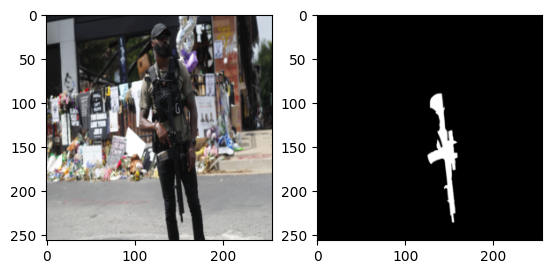

0 <-> 0
1 <-> 1
2 <-> 2
3 <-> 3
4 <-> 4
5 <-> 5
6 <-> 6
7 <-> 7
8 <-> 8
9 <-> 9


In [12]:
img, mask = train_dataset[0]
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img.permute(1,2,0))
ax[1].imshow(mask.squeeze(), cmap='gray')
plt.show()
for i in range(10):
    print(Path(train_dataset.images[i]).stem, "<->", Path(train_dataset.masks[i]).stem)

Цикл обучения

Epoch [15/15], loss_mean = 1.164336: 100%|██████████| 6/6 [00:01<00:00,  3.77it/s]


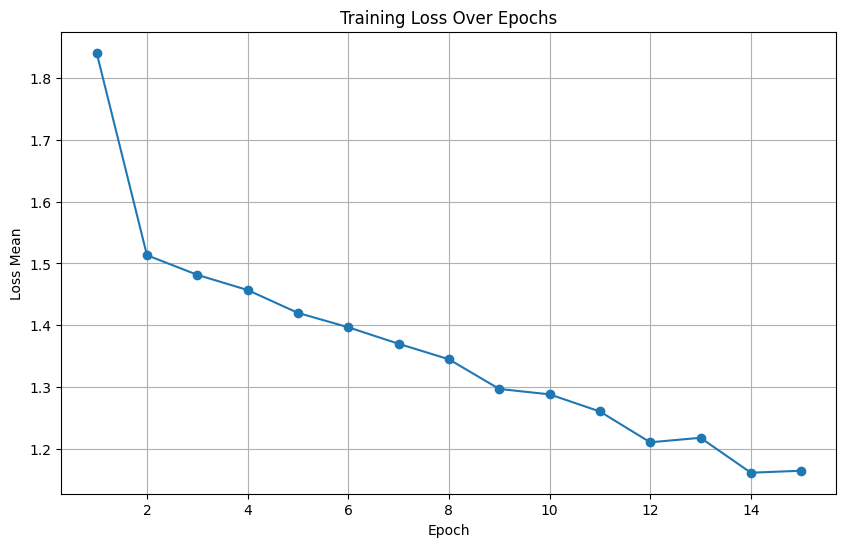

In [13]:
from tqdm import tqdm

epoch_losses = [] # List to store loss_mean for each epoch

for epoch in range(epochs):
  loss_mean = 0
  lm_count = 0

  train_tqdm = tqdm(train_data, leave = True)

  for x_train, y_train in train_tqdm:
    x_train = x_train.to(device)
    y_train = y_train.to(device)

    predict = model(x_train)
    loss = loss1(predict, y_train) + loss2(predict, y_train).mean()

    optimazer.zero_grad()
    loss.backward()
    optimazer.step()

    lm_count +=1
    loss_mean = 1 / lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
    train_tqdm.set_description(f"Epoch [{epoch + 1 }/{epochs}], loss_mean = {loss_mean:2f}")

  epoch_losses.append(loss_mean) # Store loss_mean for the current epoch

state = model.state_dict()
torch.save(state, "people-with-guns-segmentation-and-detection/model")

# Plotting the loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss Mean')
plt.grid(True)
plt.show()

In [24]:
model.eval()
img = io.read_image("people-with-guns-segmentation-and-detection/images.png")
# Apply the same transformations as during training
img_transformed = img_tr(img).unsqueeze(0).to(device)
pred = model(img_transformed)

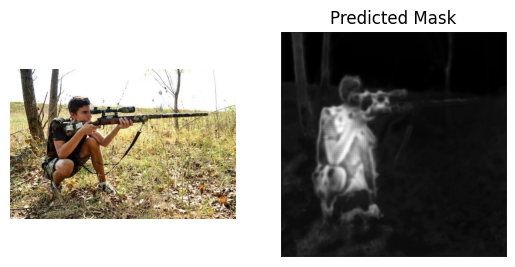

In [29]:
pred_prob = torch.sigmoid(pred)
pred_mask  = pred_prob.squeeze().detach().cpu().numpy()
fig, ax = plt.subplots(1, 2)
ax[0].imshow(img.permute(1,2,0))
ax[1].imshow(pred_mask, cmap='gray')
ax[1].set_title('Predicted Mask')
ax[0].axis('off')
ax[1].axis('off')
plt.show()


Очевидно что на столь маленьком датасете из 11 изображений модель типа U-Net  с огромным кол-вом весов
- BatchNorm2d с batch_size=2. BatchNorm считает статистики (mean/var) по батчу что очень не репрезентативно на 2х картинках

- Однако цель этого блокнота была просто собрать руками рабочую модель U-Net, что в конечном этоге было выполнено успешно